# Model Training: Telco Customer Churn Prediction

This notebook trains and evaluates two models for churn prediction:
1. **Logistic Regression** — linear, interpretable, needs feature scaling
2. **Random Forest** — non-linear, captures feature interactions

Both are compared against the baseline (majority class predictor) from the EDA notebook.

In [ ]:
import os
import sys
import io
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
from baseline import BaselineModel

## Load Data from Google Cloud Storage

In [5]:
from google.cloud import storage

BUCKET_NAME = 'greencart-churn-regression'
PROJECT_ID = 'mlip-485615'

gcs_client = storage.Client(project=PROJECT_ID)
bucket = gcs_client.bucket(BUCKET_NAME)

blob = bucket.blob('inputs/telco_customer_churn.csv')
csv_bytes = blob.download_as_bytes()
df = pd.read_csv(io.BytesIO(csv_bytes))

print(f'Loaded {df.shape[0]} rows, {df.shape[1]} columns from gs://{BUCKET_NAME}/inputs/telco_customer_churn.csv')
df.head()

Loaded 7043 rows, 21 columns from gs://greencart-churn-regression/inputs/telco_customer_churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preparation

Clean the data and split into train/validation/test (60/20/20).

In [6]:
# Clean: TotalCharges has blank strings, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Encode Churn as binary if needed
if not pd.api.types.is_numeric_dtype(df['Churn']):
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# Drop customerID if present
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

print(f'Cleaned: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Churn rate: {df.Churn.mean()*100:.1f}%')

Cleaned: 7043 rows, 20 columns
Churn rate: 26.5%


In [7]:
# Define feature types
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                        'PhoneService', 'MultipleLines', 'InternetService',
                        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies',
                        'Contract', 'PaperlessBilling', 'PaymentMethod']
target = 'Churn'

# Convert SeniorCitizen to string for consistent one-hot encoding
df['SeniorCitizen'] = df['SeniorCitizen'].astype(str)

X = df[numerical_features + categorical_features].copy()
y = df[target].copy()

# Split: 60% train, 20% val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print('Split sizes:')
for name, xs, ys in [('Train', X_train, y_train), ('Validation', X_val, y_val), ('Test', X_test, y_test)]:
    print(f'  {name:12}: {len(xs):5} samples ({ys.mean()*100:.1f}% churn)')

Split sizes:
  Train       :  4225 samples (26.5% churn)
  Validation  :  1409 samples (26.5% churn)
  Test        :  1409 samples (26.5% churn)


In [8]:
# Preprocessing: scale numericals, one-hot encode categoricals
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

# Feature names for interpretation
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(numerical_features) + list(cat_feature_names)

print(f'Processed features: {X_train_processed.shape[1]}')
print(f'  Numerical: {len(numerical_features)}')
print(f'  Categorical (after encoding): {len(cat_feature_names)}')

Processed features: 30
  Numerical: 3
  Categorical (after encoding): 27


In [9]:
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall': recall_score(y, y_pred, zero_division=0),
        'F1-Score': f1_score(y, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y, y_proba),
    }

## Baseline (reference)

Re-run the baseline here so all metrics are in one place.

In [10]:
baseline = BaselineModel()
baseline.fit(X_train_processed, y_train)

baseline_train = evaluate_model(baseline, X_train_processed, y_train)
baseline_val = evaluate_model(baseline, X_val_processed, y_val)

print('Baseline - Train:')
for k, v in baseline_train.items():
    print(f'  {k:12}: {v:.4f}')
print('\nBaseline - Validation:')
for k, v in baseline_val.items():
    print(f'  {k:12}: {v:.4f}')

Baseline - Train:
  Accuracy    : 0.7347
  Precision   : 0.0000
  Recall      : 0.0000
  F1-Score    : 0.0000
  ROC-AUC     : 0.5000

Baseline - Validation:
  Accuracy    : 0.7346
  Precision   : 0.0000
  Recall      : 0.0000
  F1-Score    : 0.0000
  ROC-AUC     : 0.5000


## Model 1: Logistic Regression

Linear classifier with hyperparameter tuning via 5-fold cross-validation. Uses `class_weight='balanced'` to handle the ~73/27 class imbalance.

In [11]:
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

lr_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    lr_param_grid, cv=5, scoring='f1', n_jobs=-1
)
lr_search.fit(X_train_processed, y_train)

lr_model = lr_search.best_estimator_
print(f'Best LR params: {lr_search.best_params_}')
print(f'Best CV F1: {lr_search.best_score_:.4f}')

lr_train = evaluate_model(lr_model, X_train_processed, y_train)
lr_val = evaluate_model(lr_model, X_val_processed, y_val)

print('\nLogistic Regression - Train:')
for k, v in lr_train.items():
    print(f'  {k:12}: {v:.4f}')
print('\nLogistic Regression - Validation:')
for k, v in lr_val.items():
    print(f'  {k:12}: {v:.4f}')

print(f'\nConfusion Matrix (Validation):')
print(confusion_matrix(y_val, lr_model.predict(X_val_processed)))
print(f'\n{classification_report(y_val, lr_model.predict(X_val_processed), target_names=["Not Churned", "Churned"])}')

/Users/matiascam/Documents/2_Education/ESMT/ml-production/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/matiascam/Documents/2_Education/ESMT/ml-production/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/matiascam/Documents/2_Education/ESMT/ml-production/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_

Best LR params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1: 0.6350

Logistic Regression - Train:
  Accuracy    : 0.7569
  Precision   : 0.5273
  Recall      : 0.8100
  F1-Score    : 0.6388
  ROC-AUC     : 0.8522

Logistic Regression - Validation:
  Accuracy    : 0.7544
  Precision   : 0.5248
  Recall      : 0.7914
  F1-Score    : 0.6311
  ROC-AUC     : 0.8361

Confusion Matrix (Validation):
[[767 268]
 [ 78 296]]

              precision    recall  f1-score   support

 Not Churned       0.91      0.74      0.82      1035
     Churned       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



/Users/matiascam/Documents/2_Education/ESMT/ml-production/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


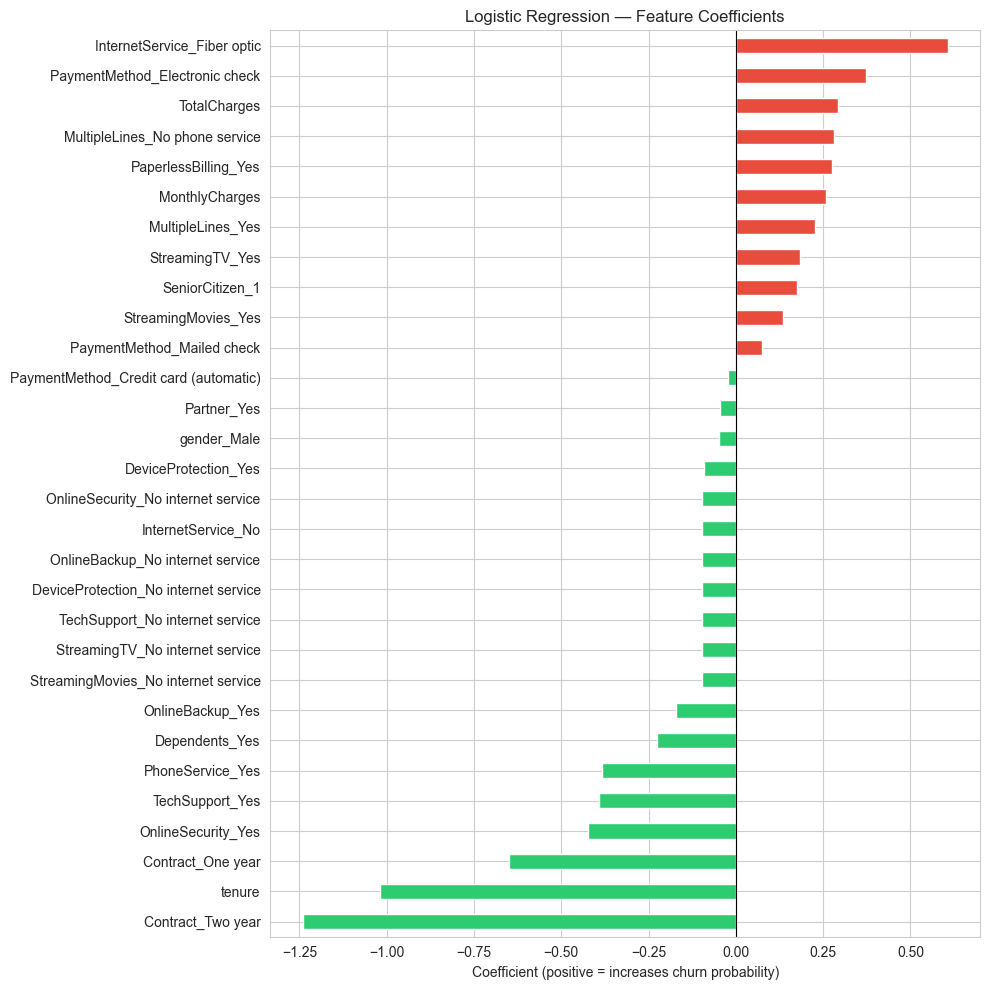

In [12]:
# Feature coefficients
lr_coefs = pd.Series(lr_model.coef_[0], index=all_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
lr_coefs.plot(kind='barh', ax=ax, color=['#e74c3c' if x > 0 else '#2ecc71' for x in lr_coefs])
ax.set_xlabel('Coefficient (positive = increases churn probability)')
ax.set_title('Logistic Regression — Feature Coefficients')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Model 2: Random Forest

Non-linear ensemble with hyperparameter tuning. Constrained (`max_depth`, `min_samples_leaf`) to prevent overfitting.

In [13]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_leaf': [5, 10, 20],
    'class_weight': ['balanced'],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring='f1', n_jobs=-1
)
rf_search.fit(X_train_processed, y_train)

rf_model = rf_search.best_estimator_
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV F1: {rf_search.best_score_:.4f}')

rf_train = evaluate_model(rf_model, X_train_processed, y_train)
rf_val = evaluate_model(rf_model, X_val_processed, y_val)

print('\nRandom Forest - Train:')
for k, v in rf_train.items():
    print(f'  {k:12}: {v:.4f}')
print('\nRandom Forest - Validation:')
for k, v in rf_val.items():
    print(f'  {k:12}: {v:.4f}')

print(f'\nConfusion Matrix (Validation):')
print(confusion_matrix(y_val, rf_model.predict(X_val_processed)))
print(f'\n{classification_report(y_val, rf_model.predict(X_val_processed), target_names=["Not Churned", "Churned"])}')

Best RF params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV F1: 0.6368

Random Forest - Train:
  Accuracy    : 0.8036
  Precision   : 0.5909
  Recall      : 0.8439
  F1-Score    : 0.6951
  ROC-AUC     : 0.8991

Random Forest - Validation:
  Accuracy    : 0.7601
  Precision   : 0.5335
  Recall      : 0.7674
  F1-Score    : 0.6294
  ROC-AUC     : 0.8381

Confusion Matrix (Validation):
[[784 251]
 [ 87 287]]

              precision    recall  f1-score   support

 Not Churned       0.90      0.76      0.82      1035
     Churned       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



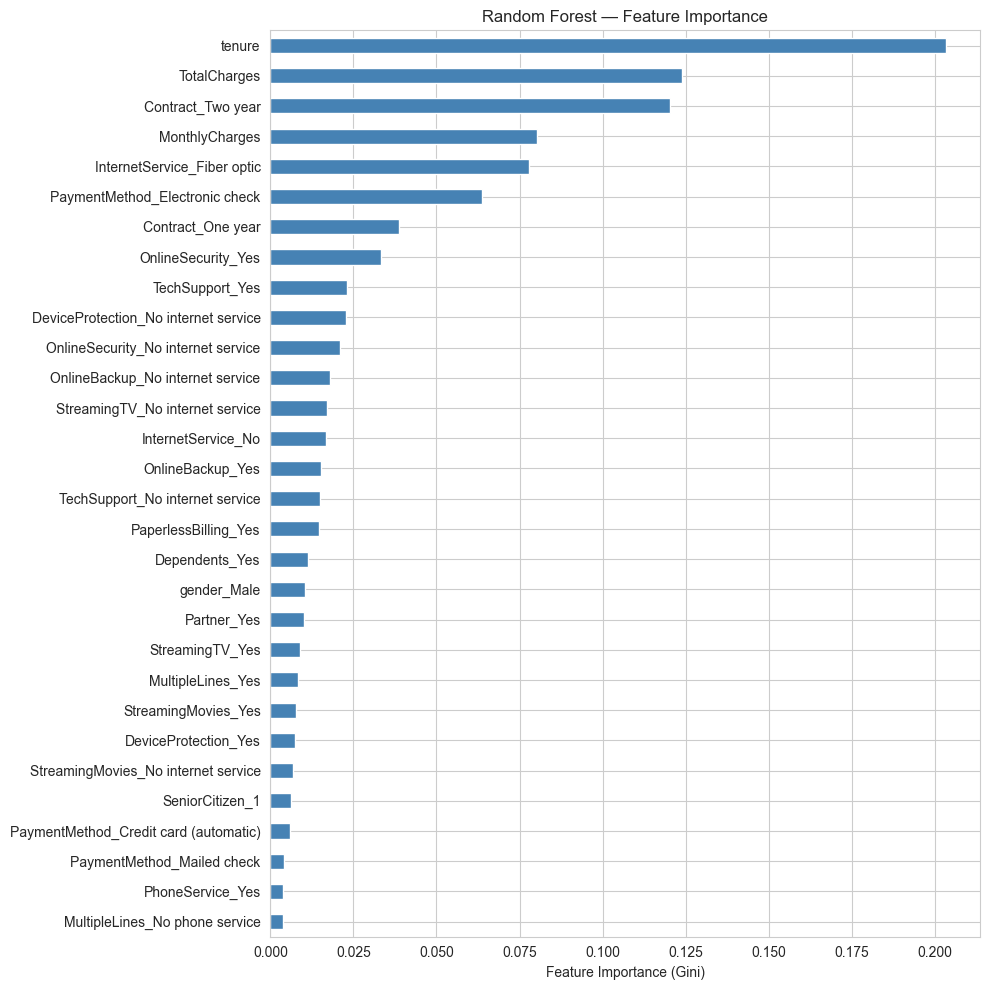

In [14]:
# Feature importance
rf_importances = pd.Series(rf_model.feature_importances_, index=all_feature_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
rf_importances.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest — Feature Importance')
plt.tight_layout()
plt.show()

## Overfitting Check

Compare training vs validation metrics. A large gap indicates overfitting.

In [15]:
print('Train vs Validation Gap (train - val):')
print('=' * 75)
print(f'{"Metric":12} {"LR Train":>10} {"LR Val":>10} {"LR Gap":>10} {"RF Train":>10} {"RF Val":>10} {"RF Gap":>10}')
print('-' * 75)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']:
    lr_gap = lr_train[metric] - lr_val[metric]
    rf_gap = rf_train[metric] - rf_val[metric]
    print(f'{metric:12} {lr_train[metric]:10.4f} {lr_val[metric]:10.4f} {lr_gap:+10.4f} {rf_train[metric]:10.4f} {rf_val[metric]:10.4f} {rf_gap:+10.4f}')

Train vs Validation Gap (train - val):
Metric         LR Train     LR Val     LR Gap   RF Train     RF Val     RF Gap
---------------------------------------------------------------------------
Accuracy         0.7569     0.7544    +0.0025     0.8036     0.7601    +0.0434
Precision        0.5273     0.5248    +0.0025     0.5909     0.5335    +0.0574
Recall           0.8100     0.7914    +0.0185     0.8439     0.7674    +0.0765
F1-Score         0.6388     0.6311    +0.0076     0.6951     0.6294    +0.0657
ROC-AUC          0.8522     0.8361    +0.0161     0.8991     0.8381    +0.0610


## Model Comparison

Compare all three approaches on validation metrics. Primary metric: **F1-Score**.

In [16]:
comparison = pd.DataFrame({
    'Baseline': baseline_val,
    'Logistic Regression': lr_val,
    'Random Forest': rf_val,
})
comparison.index.name = 'Metric'

print('Validation Metrics Comparison:')
print('=' * 60)
print(comparison.round(4).to_string())

print('\nBest model per metric:')
for metric in comparison.index:
    best = comparison.loc[metric].idxmax()
    print(f'  {metric:12}: {best} ({comparison.loc[metric, best]:.4f})')

Validation Metrics Comparison:
           Baseline  Logistic Regression  Random Forest
Metric                                                 
Accuracy     0.7346               0.7544         0.7601
Precision    0.0000               0.5248         0.5335
Recall       0.0000               0.7914         0.7674
F1-Score     0.0000               0.6311         0.6294
ROC-AUC      0.5000               0.8361         0.8381

Best model per metric:
  Accuracy    : Random Forest (0.7601)
  Precision   : Random Forest (0.5335)
  Recall      : Logistic Regression (0.7914)
  F1-Score    : Logistic Regression (0.6311)
  ROC-AUC     : Random Forest (0.8381)


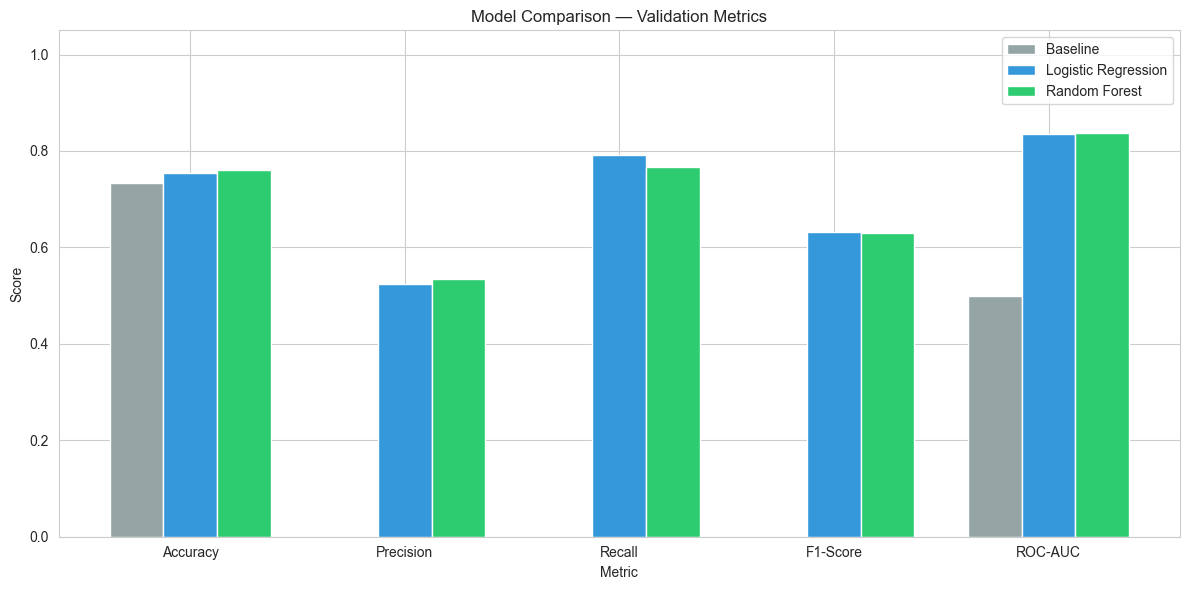

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison.index))
width = 0.25

ax.bar(x - width, comparison['Baseline'], width, label='Baseline', color='#95a5a6')
ax.bar(x, comparison['Logistic Regression'], width, label='Logistic Regression', color='#3498db')
ax.bar(x + width, comparison['Random Forest'], width, label='Random Forest', color='#2ecc71')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Validation Metrics')
ax.set_xticks(x)
ax.set_xticklabels(comparison.index)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

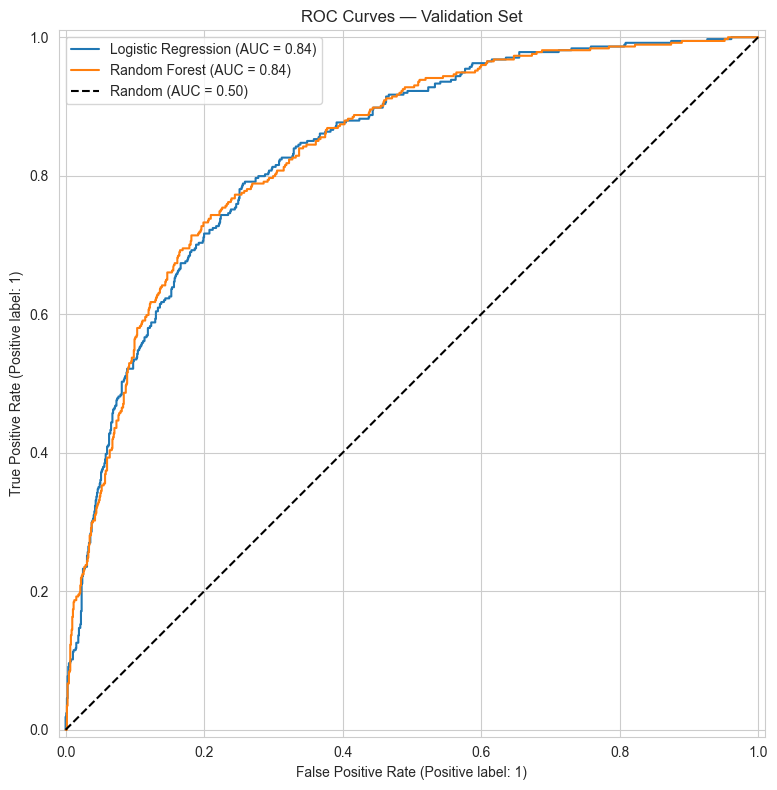

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
RocCurveDisplay.from_estimator(lr_model, X_val_processed, y_val, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(rf_model, X_val_processed, y_val, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
ax.set_title('ROC Curves — Validation Set')
ax.legend()
plt.tight_layout()
plt.show()

## Save Metrics to GCS

In [19]:
metrics_csv = comparison.round(4).to_csv()
blob = bucket.blob('outputs/model_comparison_metrics.csv')
blob.upload_from_string(metrics_csv, content_type='text/csv')

print(f'Metrics saved to gs://{BUCKET_NAME}/outputs/model_comparison_metrics.csv')
print(comparison.round(4))

Metrics saved to gs://greencart-churn-regression/outputs/model_comparison_metrics.csv
           Baseline  Logistic Regression  Random Forest
Metric                                                 
Accuracy     0.7346               0.7544         0.7601
Precision    0.0000               0.5248         0.5335
Recall       0.0000               0.7914         0.7674
F1-Score     0.0000               0.6311         0.6294
ROC-AUC      0.5000               0.8361         0.8381


## Conclusion

Both models significantly outperform the baseline (majority-class predictor) across all metrics.

| Metric | Baseline | Logistic Regression | Random Forest |
|---|---|---|---|
| Accuracy | 0.7346 | 0.7544 | **0.7601** |
| Precision | 0.0000 | 0.5248 | **0.5335** |
| Recall | 0.0000 | **0.7914** | 0.7674 |
| F1-Score | 0.0000 | **0.6311** | 0.6294 |
| ROC-AUC | 0.5000 | 0.8361 | **0.8381** |

**Key findings:**
- **Logistic Regression** (best params: C=0.1, L2) wins on F1-Score (0.63) and Recall (0.79), meaning it catches more churners — important when the cost of missing a churner is high.
- **Random Forest** (best params: max_depth=10, min_samples_leaf=10, 100 trees) wins on Accuracy, Precision, and ROC-AUC, but by slim margins.
- Both models generalize well: the overfitting gap (train - val) is small (~1% for LR, ~4-6% for RF).
- Top predictors across both models: **tenure**, **contract type** (month-to-month), and **monthly charges**.
- The Telco dataset has genuine feature-target relationships, unlike the previous synthetic dataset which produced random-chance results.

**Model selection:** Both models perform similarly. Logistic Regression is preferred for its interpretability and slightly better recall, making it the recommended model for the training and inference pipelines.